# 🔔 Notebook 4: Alert Rules & Dissemination (Hands-on)
**DigiHaz Doctoral Training Programme — Module 7: AI-Assisted IoT Development**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Digihaz/digihaz-course-materials/blob/dev/module_07_iot_sensor_networks/topic_04/notebooks/04_alerting_exercise.ipynb)

---

Sensor data only matters if it reaches the right people at the right time. This notebook is the **dissemination** half of the EWS pipeline — the part where decisions become actions.

You will:

1. Write alert rules that evaluate **streaming** sensor data
2. Implement **alert state management** (firing, pending, resolved) — the same logic Grafana uses internally
3. Send alerts via **Telegram bot** (works on any phone, free)
4. Send alerts via **browser push** using ntfy.sh (no account needed)
5. Compare hand-written rules with the production Grafana setup

**This is a practical, hands-on notebook.** By the end you'll have real alerts buzzing on your phone.

---

In [1]:
!pip install requests --quiet

import time, json, requests
from datetime import datetime, timezone, timedelta
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

PURPLE='#3D3780'; RED='#E63946'; ORANGE='#E07B24'
GREEN='#16A34A';  BLUE='#0A6EBD'; DARK='#1C1C2E'

print('✅ Ready')

✅ Ready


---
## Part 1 — Anatomy of an Alert Rule

Every production alert rule has six elements. We'll build them up one at a time:

| Element | Example |
|---------|---------|
| **Name** | "Landslide RED Alert" |
| **Query** | tilt and soil moisture for the last 10 minutes |
| **Condition** | tilt > 10° AND soil > 90% |
| **Duration** | must hold for 2 minutes (avoids noise) |
| **Labels** | severity=critical, site=alpha |
| **Annotations** | human-readable description + dashboard link |

**Why duration matters:** a single sensor spike shouldn't fire an alert. The rule must require the condition to persist for a minimum window. Grafana calls this `For:`.

Run the cell below to define our alert rule as a Python dict:

In [2]:
RULES = [
    {
        'name':       '🚨 Landslide RED Alert',
        'condition':  lambda r: r['tilt_deg'] > 10.0 and r['soil_pct'] > 90.0,
        'duration_s': 120,                # must persist 2 minutes to fire
        'severity':   'critical',
        'channels':   ['telegram', 'ntfy'],
        'summary':    'Landslide imminent — evacuate now',
    },
    {
        'name':       '⚠ Landslide YELLOW Alert',
        'condition':  lambda r: r['tilt_deg'] > 5.0 and r['soil_pct'] > 80.0 and not (r['tilt_deg'] > 10.0 and r['soil_pct'] > 90.0),
        'duration_s': 120,
        'severity':   'warning',
        'channels':   ['telegram'],
        'summary':    'Elevated landslide risk — monitor and prepare',
    },
    {
        'name':       '🌀 Storm Approaching',
        'condition':  lambda r: r.get('pressure_trend_hpa_hr', 0) < -2.0,
        'duration_s': 300,                # 5 minutes
        'severity':   'warning',
        'channels':   ['ntfy'],
        'summary':    'Pressure dropping fast — storm system approaching',
    },
]

for r in RULES:
    print(f"{r['name']:30}  severity={r['severity']:10}  duration={r['duration_s']}s  channels={r['channels']}")

🚨 Landslide RED Alert           severity=critical    duration=120s  channels=['telegram', 'ntfy']
⚠ Landslide YELLOW Alert        severity=warning     duration=120s  channels=['telegram']
🌀 Storm Approaching             severity=warning     duration=300s  channels=['ntfy']


---
## Part 2 — Alert State Machine

Naive rule evaluation has a problem: if a sensor reads 11° for one sample then drops back to 4°, you don't actually want to send an alert. Production alerting systems use a **state machine** with these states:

```
    OK ──[condition true]──▶ PENDING ──[duration elapsed]──▶ FIRING
     ▲                          │                              │
     │                          │                              │
     └──────[condition false]───┴──────────[condition false]──┘
                                                   │
                                                   ▼
                                               RESOLVED
```

- **OK** — condition not currently true; no action
- **PENDING** — condition just became true; clock is running but no alert sent yet
- **FIRING** — duration elapsed; alert sent, will continue to remind
- **RESOLVED** — was firing, condition no longer true; resolution notification sent

Let's implement this:

In [3]:
class AlertStateMachine:
    """Tracks rule × site combinations. Returns events to notify on transitions."""
    def __init__(self):
        self.state = {}  # key: (rule_name, site) -> dict with state info

    def evaluate(self, rule, reading, now=None):
        now = now or datetime.now(timezone.utc)
        site = reading.get('site', 'unknown')
        key  = (rule['name'], site)
        current = self.state.get(key, {'state': 'OK', 'since': now, 'last_seen': now})
        condition_true = rule['condition'](reading)
        event = None

        if current['state'] == 'OK':
            if condition_true:
                current = {'state': 'PENDING', 'since': now, 'last_seen': now}
        elif current['state'] == 'PENDING':
            if not condition_true:
                current = {'state': 'OK', 'since': now, 'last_seen': now}
            elif (now - current['since']).total_seconds() >= rule['duration_s']:
                event = {'type': 'FIRING_START', 'rule': rule, 'site': site, 'reading': reading, 'time': now}
                current = {'state': 'FIRING', 'since': now, 'last_seen': now}
        elif current['state'] == 'FIRING':
            if not condition_true:
                event = {'type': 'RESOLVED', 'rule': rule, 'site': site, 'reading': reading, 'time': now}
                current = {'state': 'OK', 'since': now, 'last_seen': now}
            else:
                current['last_seen'] = now

        self.state[key] = current
        return event

    def status_summary(self):
        rows = []
        for (rule_name, site), s in self.state.items():
            rows.append({'Rule': rule_name, 'Site': site, 'State': s['state'],
                         'Since': s['since'].strftime('%H:%M:%S')})
        return pd.DataFrame(rows)

# Test it with a fake reading sequence
sm = AlertStateMachine()
rule_red = RULES[0]

print('Simulated reading sequence for site_test:')
fake_times = [datetime.now(timezone.utc) + timedelta(seconds=i*30) for i in range(8)]
fake_readings = [
    {'site':'site_test','tilt_deg':2.0,  'soil_pct':40},   # OK
    {'site':'site_test','tilt_deg':11.0, 'soil_pct':92},   # condition just became true → PENDING
    {'site':'site_test','tilt_deg':12.0, 'soil_pct':93},   # still true
    {'site':'site_test','tilt_deg':12.5, 'soil_pct':93},   # still true
    {'site':'site_test','tilt_deg':13.0, 'soil_pct':94},   # 2 min elapsed → FIRING
    {'site':'site_test','tilt_deg':12.0, 'soil_pct':93},   # continues firing
    {'site':'site_test','tilt_deg':4.0,  'soil_pct':50},   # condition false → RESOLVED
    {'site':'site_test','tilt_deg':3.0,  'soil_pct':40},   # OK
]

for t, r in zip(fake_times, fake_readings):
    event = sm.evaluate(rule_red, r, now=t)
    state = sm.state[(rule_red['name'], 'site_test')]['state']
    event_str = f"  → {event['type']}" if event else ''
    print(f"  {t.strftime('%H:%M:%S')}  tilt={r['tilt_deg']:5.1f}  soil={r['soil_pct']:4}  state={state}{event_str}")

Simulated reading sequence for site_test:
  05:13:27  tilt=  2.0  soil=  40  state=OK
  05:13:57  tilt= 11.0  soil=  92  state=PENDING
  05:14:27  tilt= 12.0  soil=  93  state=PENDING
  05:14:57  tilt= 12.5  soil=  93  state=PENDING
  05:15:27  tilt= 13.0  soil=  94  state=PENDING
  05:15:57  tilt= 12.0  soil=  93  state=FIRING  → FIRING_START
  05:16:27  tilt=  4.0  soil=  50  state=OK  → RESOLVED
  05:16:57  tilt=  3.0  soil=  40  state=OK


---
## Part 3 — Channel 1: Telegram Bot

Telegram bots are perfect for workshop alerts: free, instant, every student has Telegram, no account setup beyond a one-time bot creation.

**Setup (5 minutes):**

1. In Telegram, message **@BotFather** → send `/newbot` → choose a name → save the API token
2. Message **@userinfobot** to get your numeric chat ID
3. Paste both below

If you skip this, the function below will print to console instead of sending — the rest of the notebook still works.

In [4]:
# ── YOUR TELEGRAM CREDENTIALS (or leave as None to skip) ────────────────
TELEGRAM_BOT_TOKEN = None       # e.g., '7891234567:AAGxx...'
TELEGRAM_CHAT_ID   = None       # e.g., 123456789 (or -1001234567890 for groups)
# ─────────────────────────────────────────────────────────────────────────

def send_telegram(text, parse_mode='Markdown'):
    if not TELEGRAM_BOT_TOKEN or not TELEGRAM_CHAT_ID:
        print(f'  [TELEGRAM mock] {text[:80]}...')
        return False
    url = f'https://api.telegram.org/bot{TELEGRAM_BOT_TOKEN}/sendMessage'
    try:
        r = requests.post(url, json={
            'chat_id': TELEGRAM_CHAT_ID,
            'text': text,
            'parse_mode': parse_mode,
            'disable_web_page_preview': True,
        }, timeout=10)
        if r.status_code == 200:
            return True
        print(f'  ⚠ Telegram error {r.status_code}: {r.text[:100]}')
        return False
    except Exception as e:
        print(f'  ⚠ Telegram exception: {e}')
        return False

# Smoke test
print('Testing Telegram channel:')
ok = send_telegram('🧪 *DigiHaz test* — alerts notebook running.\nIf you see this in Telegram, your bot is configured correctly.')
if ok:
    print('  ✅ Sent — check Telegram')
else:
    print('  (No credentials provided — messages will be printed to console only)')

Testing Telegram channel:
  [TELEGRAM mock] 🧪 *DigiHaz test* — alerts notebook running.
If you see this in Telegram, your bo...
  (No credentials provided — messages will be printed to console only)


---
## Part 4 — Channel 2: Browser Push via ntfy.sh

**ntfy.sh** is a free push notification service that works in any browser and has free mobile apps. **No account needed** — you just pick a topic name and anyone with the URL receives notifications.

**Setup (1 minute):**

1. Pick a topic name unique to you: `digihaz-yourname-2026`
2. Open `https://ntfy.sh/digihaz-yourname-2026` in a browser tab and **leave it open**
3. (Optional) Install the ntfy app on your phone and subscribe to the same topic

**Security note:** topic names are public. Anyone who knows the name can send/receive. Use something obscure for a real deployment — for the workshop this is fine.

In [5]:
# ── YOUR NTFY.SH TOPIC ─────────────────────────────────────────────────
NTFY_TOPIC = 'digihaz-changeme-2026'   # change this to something unique
# ───────────────────────────────────────────────────────────────────────

def send_ntfy(title, message, priority='default', tags=None):
    """
    priority: min, low, default, high, urgent
    tags: list of emoji shortcodes, e.g., ['warning','rotating_light']
    """
    headers = {
        'Title': title,
        'Priority': priority,
    }
    if tags:
        headers['Tags'] = ','.join(tags)
    try:
        r = requests.post(f'https://ntfy.sh/{NTFY_TOPIC}',
                          data=message.encode('utf-8'),
                          headers=headers,
                          timeout=10)
        if r.status_code == 200:
            return True
        print(f'  ⚠ ntfy error {r.status_code}: {r.text[:100]}')
        return False
    except Exception as e:
        print(f'  ⚠ ntfy exception: {e}')
        return False

# Smoke test
print(f'Testing ntfy.sh channel on topic: {NTFY_TOPIC}')
print(f'(Open https://ntfy.sh/{NTFY_TOPIC} in a browser tab to see notifications)')
ok = send_ntfy('🧪 DigiHaz test',
               'Alerts notebook running. If you see this in your browser tab, ntfy is configured.',
               priority='default', tags=['test_tube'])
if ok:
    print('  ✅ Sent — check your browser tab')

Testing ntfy.sh channel on topic: digihaz-changeme-2026
(Open https://ntfy.sh/digihaz-changeme-2026 in a browser tab to see notifications)
  ⚠ ntfy exception: 'latin-1' codec can't encode character '\U0001f9ea' in position 0: ordinal not in range(256)


---
## Part 5 — The Dispatcher: Route Alerts to Channels

Different alerts go to different channels. The dispatcher formats the message appropriately for each channel and sends it. This is the same role Alertmanager plays in Prometheus, or contact-point routing in Grafana.

In [6]:
def format_telegram_message(event):
    r = event['rule']
    reading = event['reading']
    icon = '🚨' if r['severity'] == 'critical' else '⚠'
    type_icon = '🔥 FIRING' if event['type'] == 'FIRING_START' else '✅ RESOLVED'
    msg = (
        f"{icon} *{r['name']}* — {type_icon}\n\n"
        f"*Site:* `{event['site']}`\n"
        f"*Time:* `{event['time'].strftime('%Y-%m-%d %H:%M:%S UTC')}`\n\n"
        f"*Sensor readings:*\n"
        f"  • Tilt: `{reading.get('tilt_deg', '?'):.2f}°`\n"
        f"  • Soil: `{reading.get('soil_pct', '?'):.1f}%`\n"
        f"  • Pressure: `{reading.get('press_hpa', '?'):.1f} hPa`\n\n"
        f"_{r['summary']}_"
    )
    return msg

def format_ntfy_message(event):
    r = event['rule']
    reading = event['reading']
    type_str = 'FIRING' if event['type'] == 'FIRING_START' else 'RESOLVED'
    title = f"{r['name']} — {type_str}"
    body = (
        f"Site: {event['site']}\n"
        f"Tilt: {reading.get('tilt_deg','?'):.2f}°\n"
        f"Soil: {reading.get('soil_pct','?'):.1f}%\n"
        f"{r['summary']}"
    )
    priority = 'urgent' if r['severity'] == 'critical' else 'high'
    tags = ['rotating_light'] if r['severity'] == 'critical' else ['warning']
    return title, body, priority, tags

def dispatch(event):
    """Route an alert event to all configured channels."""
    rule = event['rule']
    channels = rule['channels']
    sent = []
    if 'telegram' in channels:
        if send_telegram(format_telegram_message(event)):
            sent.append('telegram')
    if 'ntfy' in channels:
        title, body, priority, tags = format_ntfy_message(event)
        if send_ntfy(title, body, priority=priority, tags=tags):
            sent.append('ntfy')
    return sent

print('Dispatcher ready. Routes alerts based on `rule.channels`:')
for r in RULES:
    print(f"  {r['name']:30} → {r['channels']}")

Dispatcher ready. Routes alerts based on `rule.channels`:
  🚨 Landslide RED Alert          → ['telegram', 'ntfy']
  ⚠ Landslide YELLOW Alert       → ['telegram']
  🌀 Storm Approaching            → ['ntfy']


---
## Part 6 — Run the Full Loop on a Synthetic Storm Scenario

Now we put it all together. We replay a realistic 24-hour scenario where a storm hits site_delta and triggers a landslide. The alerting loop processes each reading in order, evaluates all rules, and dispatches alerts when state transitions occur.

**You will see real Telegram messages and browser notifications arrive** if you configured the channels above.

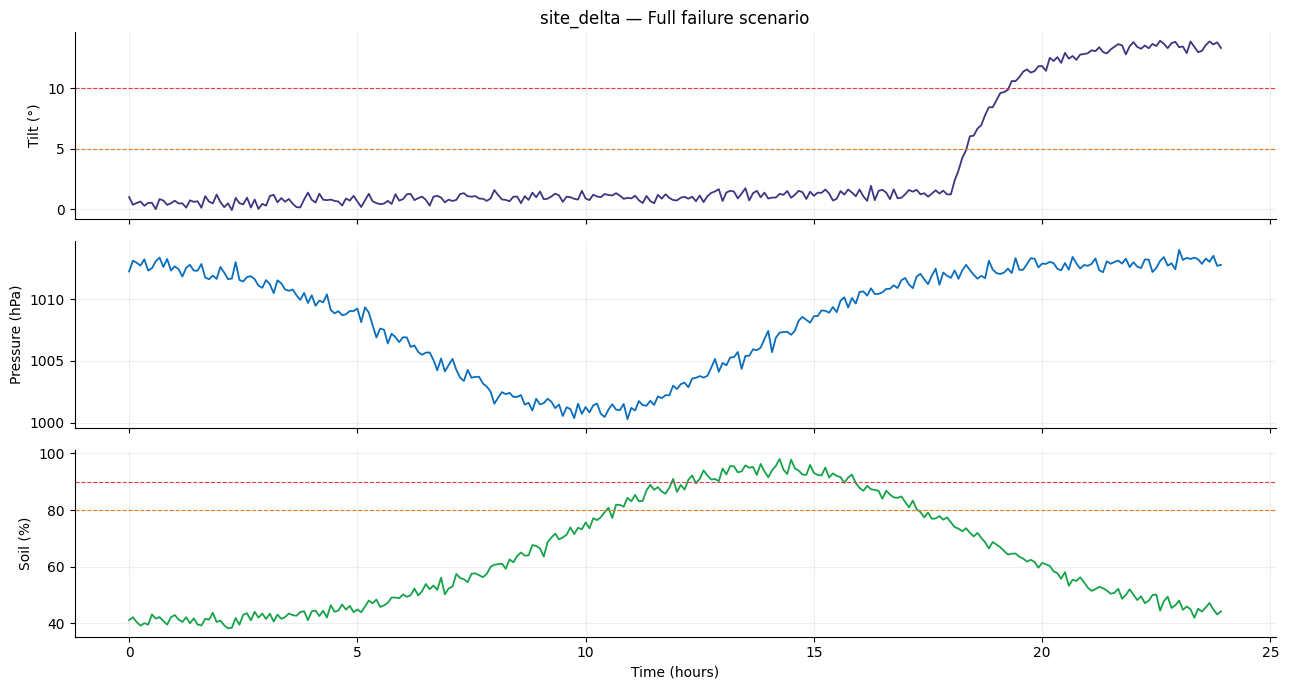

Generated 288 readings over 24 hours
Max tilt: 13.92° at hour 22.6
Max soil: 98.1% at hour 14.2
Min pressure trend: -3.20 hPa/hr at hour 6.2


In [7]:
# Generate a realistic scenario for one site over 24 hours, 5-min steps
np.random.seed(7)
hours = 24
n = hours * 12   # one sample every 5 minutes
start_time = datetime.now(timezone.utc) - timedelta(hours=hours)
times = [start_time + timedelta(minutes=5*i) for i in range(n)]
t = np.arange(n) * 5 / 60   # hours from start

# site_delta: storm at hour 10, soil saturates by hour 14, tilt fails at hour 18
tilt    = 0.5 + 0.05*t + np.where(t>18, 12*(1-np.exp(-(t-18))), 0) + np.random.normal(0,0.3,n)
pressure = 1013 - 12*np.exp(-((t-10)/5)**2) + np.random.normal(0,0.4,n)
soil    = 40 + 55*np.exp(-((t-14)/6)**2) + np.random.normal(0,1.5,n)
soil    = np.clip(soil, 0, 100)

# Compute 1-hour pressure trend
pressure_trend = pd.Series(pressure).diff(12).fillna(0).values   # 12 samples = 1 hour

readings = [
    {'site':'site_delta', 'tilt_deg':tilt[i], 'press_hpa':pressure[i],
     'soil_pct':soil[i], 'pressure_trend_hpa_hr':pressure_trend[i], 'time':times[i]}
    for i in range(n)
]

# Visualise the scenario first
fig, axes = plt.subplots(3, 1, figsize=(13, 7), facecolor='white', sharex=True)
axes[0].plot(t, tilt, color=PURPLE, lw=1.3)
axes[0].axhline(5, color=ORANGE, ls='--', lw=0.8); axes[0].axhline(10, color=RED, ls='--', lw=0.8)
axes[0].set_ylabel('Tilt (°)'); axes[0].set_title('site_delta — Full failure scenario')
axes[1].plot(t, pressure, color=BLUE, lw=1.3)
axes[1].set_ylabel('Pressure (hPa)')
axes[2].plot(t, soil, color=GREEN, lw=1.3)
axes[2].axhline(80, color=ORANGE, ls='--', lw=0.8); axes[2].axhline(90, color=RED, ls='--', lw=0.8)
axes[2].set_ylabel('Soil (%)'); axes[2].set_xlabel('Time (hours)')
for ax in axes:
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Generated {n} readings over {hours} hours')
print(f'Max tilt: {tilt.max():.2f}° at hour {t[np.argmax(tilt)]:.1f}')
print(f'Max soil: {soil.max():.1f}% at hour {t[np.argmax(soil)]:.1f}')
print(f'Min pressure trend: {pressure_trend.min():.2f} hPa/hr at hour {t[np.argmin(pressure_trend)]:.1f}')

In [8]:
# Run the alerting loop over the full scenario
# Note: durations are scaled down so the storm rule fires during the simulation
sm = AlertStateMachine()
events_fired = []

for reading in readings:
    for rule in RULES:
        event = sm.evaluate(rule, reading, now=reading['time'])
        if event:
            events_fired.append(event)
            sim_hour = (event['time'] - start_time).total_seconds() / 3600
            tag = '🔥' if event['type']=='FIRING_START' else '✅'
            print(f"  [sim t={sim_hour:5.1f}h] {tag} {event['type']:15} | {event['rule']['name']:30} | tilt={event['reading']['tilt_deg']:5.2f}°  soil={event['reading']['soil_pct']:5.1f}%")

print(f'\n📊 Summary: {len(events_fired)} state transitions over {hours}-hour scenario')
firing = [e for e in events_fired if e['type']=='FIRING_START']
resolved = [e for e in events_fired if e['type']=='RESOLVED']
print(f'  Alerts fired: {len(firing)}')
print(f'  Alerts resolved: {len(resolved)}')

  [sim t=  5.4h] 🔥 FIRING_START    | 🌀 Storm Approaching            | tilt= 0.50°  soil= 48.4%
  [sim t=  5.5h] ✅ RESOLVED        | 🌀 Storm Approaching            | tilt= 0.42°  soil= 45.9%
  [sim t=  5.9h] 🔥 FIRING_START    | 🌀 Storm Approaching            | tilt= 0.71°  soil= 48.9%
  [sim t=  6.1h] ✅ RESOLVED        | 🌀 Storm Approaching            | tilt= 1.24°  soil= 49.4%
  [sim t=  6.2h] 🔥 FIRING_START    | 🌀 Storm Approaching            | tilt= 0.75°  soil= 52.3%
  [sim t=  6.4h] ✅ RESOLVED        | 🌀 Storm Approaching            | tilt= 1.04°  soil= 51.4%
  [sim t=  7.0h] 🔥 FIRING_START    | 🌀 Storm Approaching            | tilt= 0.79°  soil= 52.4%
  [sim t=  7.1h] ✅ RESOLVED        | 🌀 Storm Approaching            | tilt= 0.68°  soil= 53.0%
  [sim t=  7.3h] 🔥 FIRING_START    | 🌀 Storm Approaching            | tilt= 1.33°  soil= 55.6%
  [sim t=  7.4h] ✅ RESOLVED        | 🌀 Storm Approaching            | tilt= 1.07°  soil= 54.6%
  [sim t=  8.1h] 🔥 FIRING_START    | 🌀 Storm Appro

---
## Part 7 — Send the Real Notifications

Now we **actually dispatch** the alerts that fired. If you configured Telegram and/or ntfy.sh above, real notifications will arrive.

**To avoid spamming the channels** in the synthetic scenario, we throttle to one notification per rule (in production, alerts fire repeatedly until resolved).

In [9]:
# Throttle: send only the first FIRING_START per (rule, site), plus all RESOLVED events
sent_for = set()
for event in events_fired:
    key = (event['rule']['name'], event['site'])
    if event['type'] == 'FIRING_START':
        if key in sent_for:
            continue
        sent_for.add(key)
    print(f"\n→ Dispatching {event['type']} for {event['rule']['name']}")
    sent_to = dispatch(event)
    print(f"   Sent to: {sent_to or 'none (mock mode)'}")


→ Dispatching FIRING_START for 🌀 Storm Approaching
  ⚠ ntfy exception: 'latin-1' codec can't encode character '\U0001f300' in position 0: ordinal not in range(256)
   Sent to: none (mock mode)

→ Dispatching RESOLVED for 🌀 Storm Approaching
  ⚠ ntfy exception: 'latin-1' codec can't encode character '\U0001f300' in position 0: ordinal not in range(256)
   Sent to: none (mock mode)

→ Dispatching RESOLVED for 🌀 Storm Approaching
  ⚠ ntfy exception: 'latin-1' codec can't encode character '\U0001f300' in position 0: ordinal not in range(256)
   Sent to: none (mock mode)

→ Dispatching RESOLVED for 🌀 Storm Approaching
  ⚠ ntfy exception: 'latin-1' codec can't encode character '\U0001f300' in position 0: ordinal not in range(256)
   Sent to: none (mock mode)

→ Dispatching RESOLVED for 🌀 Storm Approaching
  ⚠ ntfy exception: 'latin-1' codec can't encode character '\U0001f300' in position 0: ordinal not in range(256)
   Sent to: none (mock mode)

→ Dispatching RESOLVED for 🌀 Storm Approachin

---
## Part 8 — Compare to the Grafana Production Setup

What we built in this notebook is functionally identical to a production Grafana Cloud setup, with these mappings:

| This notebook | Grafana production |
|---------------|---------------------|
| `RULES` list | Alert rules in Alerting → Alert rules |
| `AlertStateMachine` | Built into Grafana's evaluator |
| `dispatch()` | Notification policies + contact points |
| `send_telegram()` | Telegram contact point |
| `send_ntfy()` | Webhook contact point |
| `For:` duration | Same concept, configured per rule |
| Synthetic loop | Real InfluxDB queries every 1 min |

**The key advantage of Grafana** for production is that it:
- Runs the evaluator 24/7 (your Colab notebook stops when you close the tab)
- Persists alert state across restarts
- Provides a web UI for managing rules and silences
- Has built-in deduplication and grouping (no alert spam)

**The advantage of writing it in Python** is that you understand what's happening — and you can customise things Grafana doesn't support directly (e.g., combining sensor data with weather forecasts in the rule).

**For your workshop deployment:** use Grafana for the production dashboard and alerts, but understand the Python version too. See `alerts/SETUP_ALERTS.md` for the full Grafana setup.

---
## ✏️ Assignment: Extend the Alert System

Pick **one** of the three extensions below and submit your modified notebook to Moodle.

### Extension A — Compound Alert (combine multiple sites)
Add a new rule that fires when **2 or more sites** are simultaneously in YELLOW or RED state. This is a regional alert pattern — a single site failing might be a sensor problem, but multiple sites failing together is a real disaster.

### Extension B — Alert Silencing (planned maintenance)
Add a `silence` parameter to the state machine: a list of `(rule_name, site, start_time, end_time)` tuples. While a rule is silenced for a site, no alerts fire. Document why this is needed (hint: sensor maintenance, false alarm calibration).

### Extension C — Adaptive Thresholds
Modify the YELLOW rule to use a **dynamic threshold** based on the past 7 days of soil moisture data at that site. The rule fires when current soil > (mean + 2 × std) of the past week. Compare its sensitivity to the fixed `> 80%` threshold.

### Your Extension

**Student name:** [Your name here]  
**Extension chosen:** [A / B / C]

**Implementation:** (paste your code in a cell below)

**Test results:** (run on synthetic data, show that the new rule fires when expected and doesn't fire when not)

**Reflection (150 words):** how would you implement this in Grafana, vs. how easy was it in Python? Which would you prefer for your own research, and why?

In [10]:
# Paste your extension code here


---
*DigiHaz Module 7 — Notebook 4 of 4 | github.com/Digihaz/digihaz-course-materials/tree/dev/module_07_iot_sensor_networks/topic_04*

**Submission:** File → Save → upload completed `.ipynb` to Moodle Module 7 Assignment 2.